## Stage 4: Model Evaluation

### 1. Objective
To determine how the model performs to unseen data, putting attention to every specific class.

### 2. Approach
Using Confusion Matrix, Error Analysis and Regression each class is test and examined looking for anomalies in predictions, explaining the reason for the majority of misclassification. Finally it's proven how the size of each class in the dataset affects the model forecast.

### 3. Implementation

In [2]:
# Import required libraries and functions
import tensorflow as tf
import pandas as pd
import numpy as np
import os
from src.visualization.plot_training import plot_confusion_matrix, plot_classification_report
from src.features.predict import predict, load_vocab
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

c:\Users\david\Documents\Projects\ticketing-classifier\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 7 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
# Load the best performing model from the model directory
current_dir = os.getcwd()
model_path = os.path.join(current_dir, '..', 'model')
best_model = tf.keras.models.load_model(os.path.join(model_path, 'best_model.keras'), compile=False)

# Load the test dataset from the processed data directory
data_dir = os.path.join(current_dir, '..', 'data', 'processed')
test_dataset_path = os.path.join(data_dir, 'test_dataset')
test_dataset = tf.data.Dataset.load(path=test_dataset_path)
test_text = pd.read_csv(os.path.join(data_dir, 'test_text.csv'))


# Load label mapping
label_mapping_path = os.path.join(model_path, 'label_mapping.csv')
label_mapping = pd.read_csv(label_mapping_path)

Input the model with new data. Lets try testing with text from my own.

In [3]:
text = ['Se ha ido la luz en el pasillo',               # The lights have gone out in the hallway
        'La cisterna no para de echar agua',            # The toilet keeps running
        'El ascensor no funciona',                      # The elevator isn't working
        'Hace frio en la UCI',                          # It's cold in the ICU
        'Tapizar sillón',                               # Reupholster the armchair
        'El wifi va muy lento',                         # The Wi-Fi is very slow
        'La barandilla de la camilla 409 está suelta']  #The rail on stretcher 409 is loose
predicted_label = [predict(t) for t in text]
print(predicted_label)

['1 - ELECTRICIDAD', '5 - FONTANERIA', '1 - ELECTRICIDAD', '3 - CALEFACCIÓN Y CLIMATIZACIÓN', 'OTHERS', '12 - ELECTROMEDICINA', '8 - MECANICA']


All the labels in the previous examples are correctly assigned. 

Creating and interface to inference easily with the model.

In [4]:
import gradio as gr
# Create Gradio interface
demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(label="Enter your text (Spanish)", lines=3),
    outputs=gr.Textbox(label="Result"),
    title="Auto-Categorization NLP Model",
    description="Enter text to process and get the predicted category.",
    flagging_mode="never"
)
demo.launch(share=False)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Going deeper in every class creating a confusion matrix and performing Error Analysis, will help to understand the model weaknesses. Extract every misclassification for a certain label and False Negatives with a certain class. For example extract the True Electromedicina predicted as Electricidad. Checking the confusion matrix to determine the biggest misclassification for every true label.

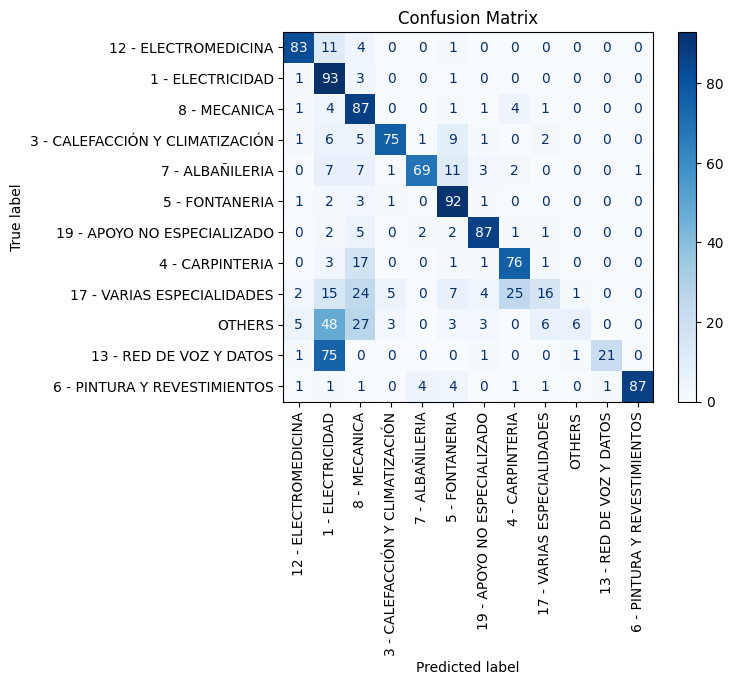

In [5]:
dataset_pred = plot_confusion_matrix(test_dataset, best_model)

Half of the classes forecast fairly well, scoring over 85.

#### Analyzing the classes with relevant amount of false negative.

12 - ELECTROMEDICINA (Electromedicine)
- 11% of the false negatives were predicted as 1 - ELECTRICIDAD (Electricity) . That is because in some cases both categories are work related (electricity) but in different devices. Adding other fields to the model from the dataset like location this misclassification can be shorted.

3 - CALEFACCION Y CLIMATIZACION (Heating and air conditioning)
- 9% where false negative misclassified in 5 - FONTANERÍA (Plumbing). Both are water conduct related, so when for example there're leaks, until the technicians go in place, they doesn't know if it's one category or another.

7 - ALBAÑILERÍA (Bricklaying)
- 11% of the predicted labels where misclassified as 5 - FONTANERÍA (Plumbing). A lot of the bricklaying work is performed in bathrooms in collaboration with the plumbing team, and because the ticketing don't allow multi-classification and the model has been trained with more plumbing the model learned that is more likely to predict correctly with 5 - FONTANERÍA.

4 - CARPINTERÍA (Carpentry)
- 17% where categorized incorrectly in 8 - MECÁNICA (Mechanic). The reason for that is that in this hospital for several moths there where no carpenter and the mechanic team replaced that labor. This lead to close ticket that in normal situation should be close by with carpenter label but it was close as mechanic. This can be sorted manually filtering those entries and correcting the labels on them.

17 - VARIAS ESPECIALIDADES (Multi-specialty)
- This class was meant to work grouping various teams, but it has no sense and at the end is used as jack-of-all-trades when someone is doing a ticket and doesn't know who should work in it. That explain why 40% of the misclassification are concentrated between 8 - MECÁNICA and 1 - ELECTRICIDAD, the more often entries. This was one of the main raison to start this project.

OTHERS
- This category is the synthetic one that was built to conglomerate all the class with so little entries. The varied natur of this class makes it hard to predict and for this reason the model is inaccurate to predict it.

13 - RED DE VOZ Y DATOS (Voice and data network)
- 75% where misclassified as 1 - ELECTRICIDAD (electricity). This is due the fact that the electric team is the first trying to sort the issue and usually they fix it and sometimes the problem is power related (electricity). Just a small amount of the ticket goes finally with the 13 - RED DE VOZ Y DATOS class.

#### Exploring if there is some correlation between precision, recall or f1-score and support.

In [6]:
report_dict = plot_classification_report(test_dataset, best_model)
report_dict = report_dict.drop(index=['accuracy','macro avg','weighted avg'])
report_dict.set_index('support', inplace=True)  # number of entries as index
report_dict.sort_values(['support'], ascending=True, inplace=True)  # sort dataframe by number of entries


Detailed Classification Report:
                                 precision    recall  f1-score   support

           12 - ELECTROMEDICINA       0.94      0.83      0.88      1853
               1 - ELECTRICIDAD       0.82      0.93      0.87      3342
                   8 - MECANICA       0.88      0.87      0.88      4870
3 - CALEFACCIÓN Y CLIMATIZACIÓN       0.89      0.75      0.82       762
                7 - ALBAÑILERIA       0.85      0.69      0.76       334
                 5 - FONTANERIA       0.87      0.92      0.89      1781
    19 - APOYO NO ESPECIALIZADO       0.85      0.87      0.86       609
                4 - CARPINTERIA       0.72      0.76      0.74      1085
     17 - VARIAS ESPECIALIDADES       0.27      0.16      0.20       225
                         OTHERS       0.15      0.06      0.09        79
        13 - RED DE VOZ Y DATOS       0.44      0.21      0.29        75
   6 - PINTURA Y REVESTIMIENTOS       0.91      0.87      0.89       158

                

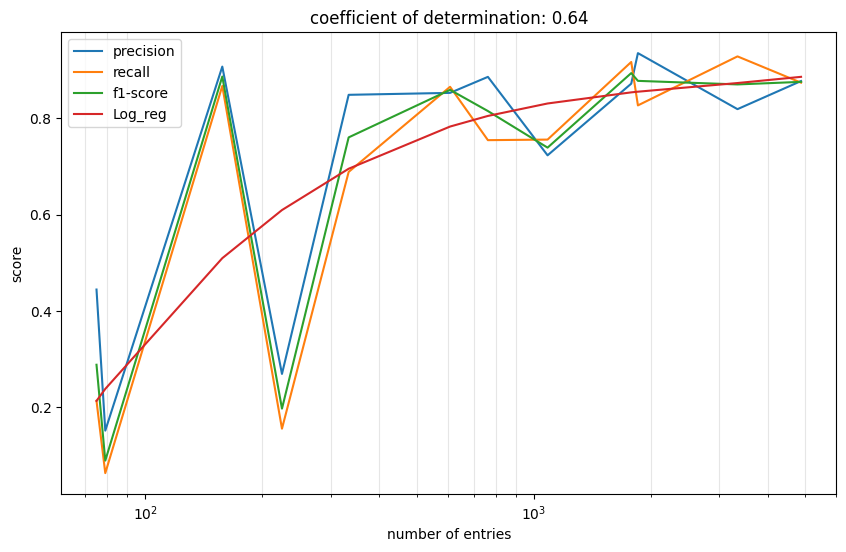

In [7]:
x = report_dict.index.values.reshape(-1,1); y = report_dict['f1-score'].values
# Log regression
x_log = np.log(x)
# Polynomial regression
x_log2 = PolynomialFeatures(degree=3, include_bias=False).fit_transform(x_log)
model = LinearRegression().fit(x_log2, y)
r_sq = model.score(x_log2, y)
y_pred = model.predict(x_log2)
report_dict['Log_reg'] = y_pred

# Plot the scores and the regression line
plt.figure(figsize=(10, 6))
plt.title(f"coefficient of determination: {r_sq:.2f}")
plt.semilogx(report_dict)
plt.legend(report_dict.columns)
plt.grid(which="minor", color="0.9")
plt.ylabel('score')
plt.xlabel('number of entries')
plt.show()

A value of 0.64 suggests a reasonably good fit for the model, as a significant portion of the dependent variable's variability is being explained. This indicates a strong relationship between the variables, but it's important to note that a high R-squared value doesn't automatically mean the model is perfect or that a cause-and-effect relationship exists. It is just a measure of how well the model's predictions align with the actual data points.

### 4. Results
For a first approach, the final forecast of the model can be mark as a success. The accuracy of the model is stablish in 85, reaching F1-Score of 89 as highest in some classes and 0.09 the lowest. Some work in the model input and in the dataset should be necessary to sort the imprecision in three of the 12 classes. Lack of entries in certain categories and mixed work related fields are the reasons for the underperformance of those classes. The model could be use and implemented because exceeds the 80% accuracy so can be stated that the model learned.

### 5. Challenges
- Finding the adequate analysis that could explain why and how the model predicts.
- Detect a second degree logarithmic regression correlation between entries for each class and model accuracy.
- Build a live interface to interact with the model easily using gradio library.

### 6. Next Steps

- Create a Multi-modal input system to accept other available fields like location to be more accurate in the prediction.
- Use attention mechanism within transformers.
- Allow multi-classification because sometimes more than one team is related to a ticket.